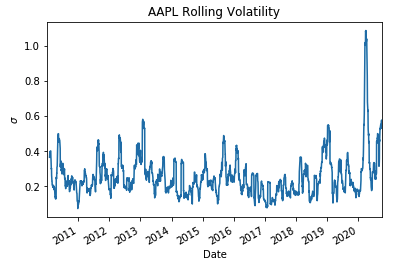

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as ss

In [3]:
def SDE_vol(v0, kappa, theta, sigma, T, M, I, rand, row, cho_matrix):
    dt = T / M  # T = maturity, M = number of time steps
    v = np.zeros((M + 1, I), dtype=float)
    v[0] = v0
    sdt = np.sqrt(dt)  # Sqrt of dt
    for t in range(1, M + 1):
        ran = np.dot(cho_matrix, rand[:, t])
        v[t] = np.maximum(0, v[t - 1] + kappa * (theta - v[t - 1]) * dt + np.sqrt(v[t - 1]) * sigma * ran[row] * sdt)
    return v

In [4]:
def Heston_paths(S0, r, v, row, cho_matrix):
    S = np.zeros((M+1, I), dtype=float)
    S[0] = S0
    sdt = np.sqrt(dt)
    for t in range(1, M+1, 1):
        ran = np.dot(cho_matrix, rand[:,t])
        S[t] = S[t - 1] * np.exp((r - 0.5 * v[t-1]) * dt + np.sqrt(v[t-1]) * ran[row] * sdt)

    return S

In [5]:
def random_number_gen(M, I):
    rand = np.random.standard_normal((2, M+1, I))
    return rand

In [6]:
v0 = 0.04
kappa_v = 2
sigma_v = 0.3
theta_v = 0.04
rho = -0.9

S0 = 100  # Current underlying asset price
r = 0.05  # Risk-free rate
M0 = 500   # Number of time steps in a year
T = 1  # Number of years
M = int(M0*T) # Total time steps
I = 10000  # Nomber of simulations
dt = T/M  # Length of time step

In [7]:
# Generating random numbers from standard normal
rand = random_number_gen(M, I)


# Covariance Matrix
covariance_matrix = np.zeros((2, 2))
covariance_matrix[0] = [1.0, rho]
covariance_matrix[1] = [rho, 1.0]
cho_matrix = np.linalg.cholesky(covariance_matrix)

In [8]:
# Volatility process paths
V = SDE_vol(v0, kappa_v, theta_v, sigma_v, T, M, I, rand, 1, cho_matrix)

# Underlying price process paths
S = Heston_paths(S0, r, V, 0, cho_matrix)

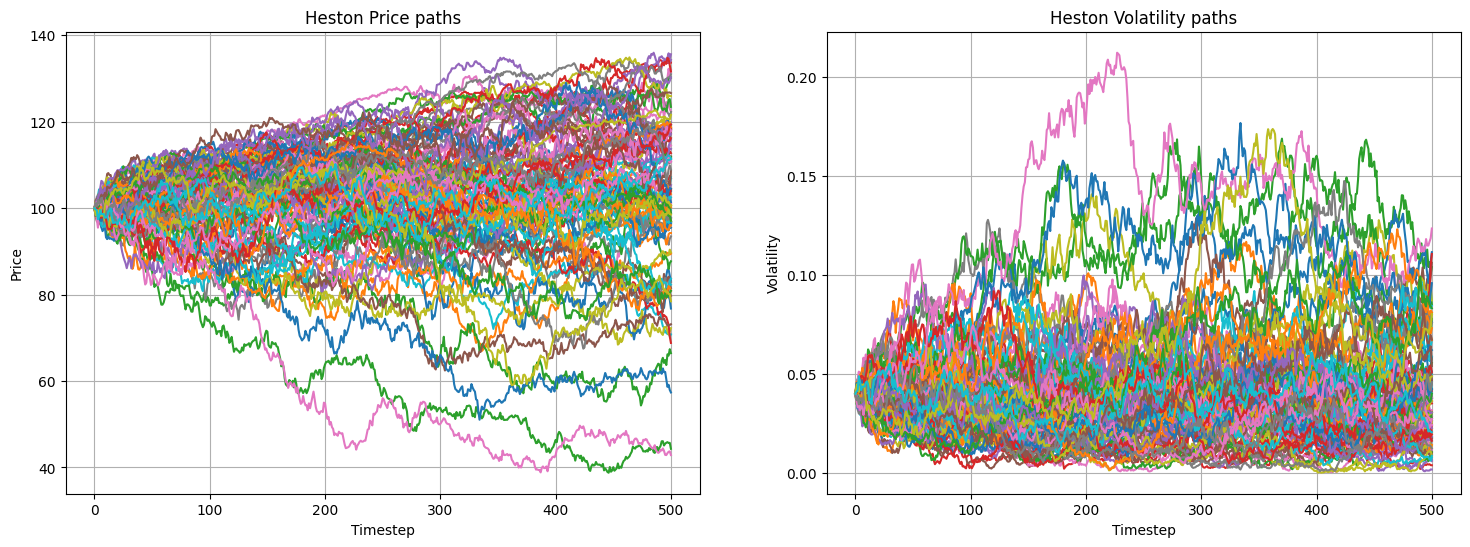

In [9]:
def plot_paths(n):
    fig = plt.figure(figsize=(18, 6))
    ax1 = fig.add_subplot(121)
    ax2 = fig.add_subplot(122)

    ax1.plot(range(len(S)), S[:, :n])
    ax1.grid()
    ax1.set_title("Heston Price paths")
    ax1.set_ylabel("Price")
    ax1.set_xlabel("Timestep")

    ax2.plot(range(len(V)), V[:, :n])
    ax2.grid()
    ax2.set_title("Heston Volatility paths")
    ax2.set_ylabel("Volatility")
    ax2.set_xlabel("Timestep")


plot_paths(100)

## 🔧 Code Task 1.1: Simulate Heston Model with New Parameters

In this task, you'll simulate new paths for both volatility and underlying price using the **Heston stochastic volatility model**.

Your tasks:

1. Set the correlation parameter to:
   - `rho_new = -0.5`

2. Update the mean-reversion speed:
   - `kappa_v_new = 1.5`

3. Reduce the number of simulations:
   - `I_new = 100` (only simulate 100 paths)

4. Simulate the **volatility paths** using the provided `SDE_vol()` function and store them in `V_new`.

5. Simulate the **price paths** using the provided `Heston_paths()` function and store them in `S_new`.

6. Use the `plot_paths(100)` function to visualize the first 100 simulated paths for both volatility and price.

Make sure to:

- Use the provided skeleton code for continuity
- Define any missing variables before using them
- Reuse the function names and structure to match the assessment checks


Stock Paths Shape: (501, 100)
Variance Paths Shape: (501, 100)


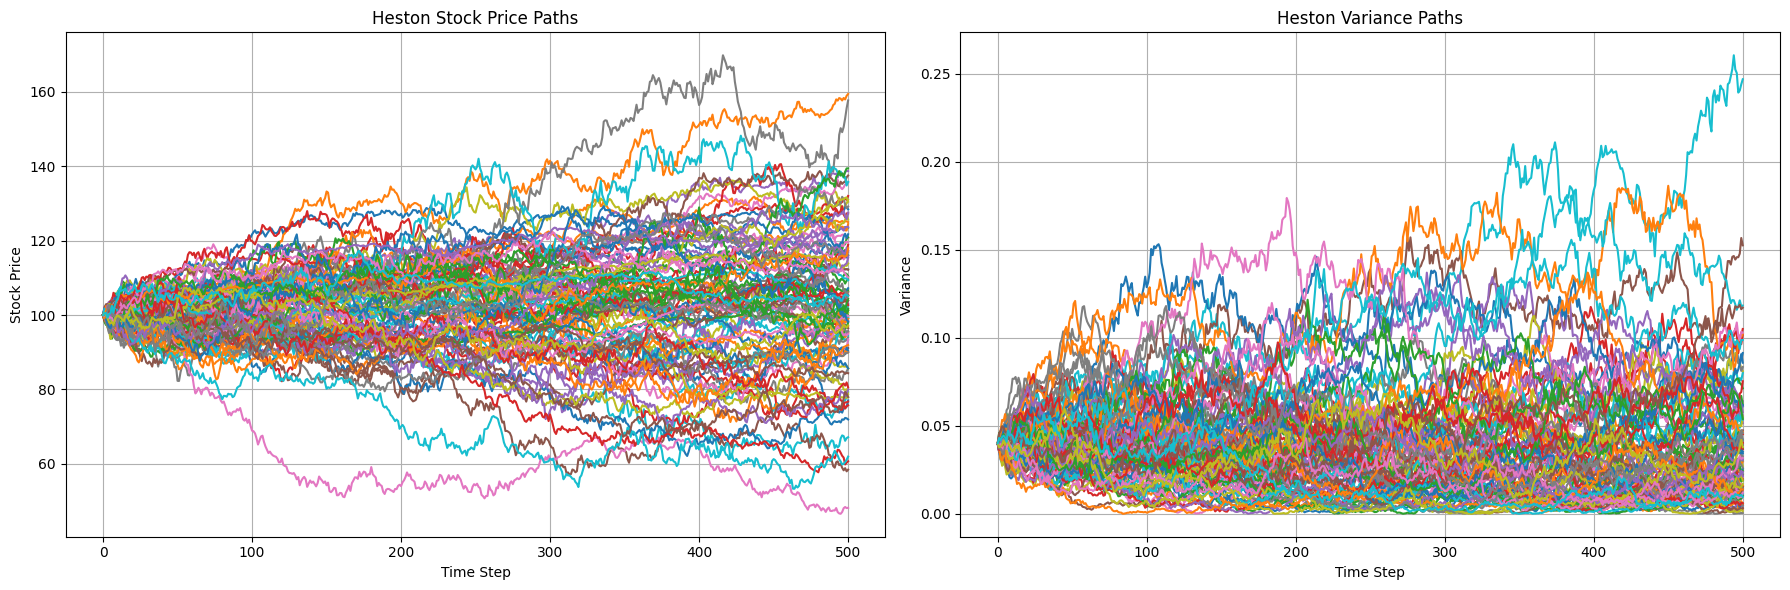

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# Heston Model Parameters
# ===============================
v0 = 0.04                 # Initial variance
kappa_v = 1.5             # Mean reversion speed
theta_v = 0.04            # Long-run variance
sigma_v = 0.3             # Volatility of variance
rho = -0.5                # Correlation

S0 = 100                  # Initial stock price
r = 0.05                  # Risk-free rate
T = 1                     # Time to maturity (years)

M0 = 500                  # Time steps per year
M = int(M0 * T)           # Total time steps
I = 100                   # Number of simulated paths

dt = T / M

# ===============================
# Correlation Matrix
# ===============================
corr_matrix = np.array([
    [1.0, rho],
    [rho, 1.0]
])

cho_matrix = np.linalg.cholesky(corr_matrix)

# ===============================
# Random Numbers
# Shape: (2, M+1, I)
# ===============================
rand = np.random.standard_normal((2, M + 1, I))

# ===============================
# Simulate Variance Paths
# ===============================
V = SDE_vol(
    v0=v0,
    kappa=kappa_v,
    theta=theta_v,
    sigma=sigma_v,
    T=T,
    M=M,
    I=I,
    rand=rand,
    row=1,
    cho_matrix=cho_matrix
)

# ===============================
# Simulate Stock Price Paths
# ===============================
S = Heston_paths(
    S0=S0,
    r=r,
    v=V,
    row=0,
    cho_matrix=cho_matrix
)

# ===============================
# Check Shapes
# ===============================
print("Stock Paths Shape:", S.shape)
print("Variance Paths Shape:", V.shape)

# ===============================
# Plot Function
# ===============================
def plot_paths(n=20):
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    axes[0].plot(S[:, :n])
    axes[0].set_title("Heston Stock Price Paths")
    axes[0].set_xlabel("Time Step")
    axes[0].set_ylabel("Stock Price")
    axes[0].grid(True)

    axes[1].plot(V[:, :n])
    axes[1].set_title("Heston Variance Paths")
    axes[1].set_xlabel("Time Step")
    axes[1].set_ylabel("Variance")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

# ===============================
# Plot 100 Paths
# ===============================
plot_paths(100)

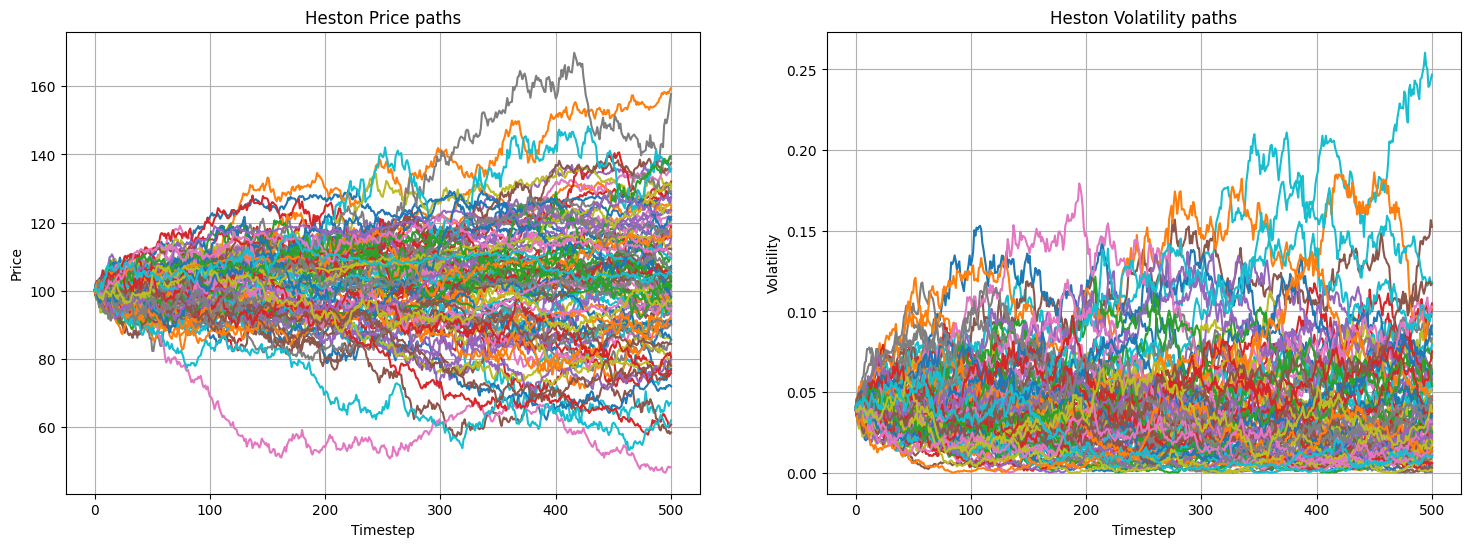

In [15]:
v0 = 0.04
kappa_v_new = 1.5
sigma_v = 0.3
theta_v = 0.04
rho_new = -0.5

S0 = 100  # Current underlying asset price
r = 0.05  # Risk-free rate
M0 = 500   # Number of time steps in a year
T = 1  # Number of years
M = int(M0*T) # Total time steps
I_new = 100  # Nomber of simulations
dt = T/M  # Length of time step

V_new = SDE_vol(v0, kappa_v_new, theta_v, sigma_v, T, M, I_new, rand, 1, cho_matrix)

S_new = Heston_paths(S0, r, V_new, 0, cho_matrix)

def plot_paths(n):
    fig = plt.figure(figsize=(18, 6))
    ax1 = fig.add_subplot(121)
    ax2 = fig.add_subplot(122)

    ax1.plot(range(len(S_new)), S_new[:, :n])
    ax1.grid()
    ax1.set_title("Heston Price paths")
    ax1.set_ylabel("Price")
    ax1.set_xlabel("Timestep")

    ax2.plot(range(len(V_new)), V_new[:, :n])
    ax2.grid()
    ax2.set_title("Heston Volatility paths")
    ax2.set_ylabel("Volatility")
    ax2.set_xlabel("Timestep")

plot_paths(100)

Text(0.5, 0, 'Log-returns')

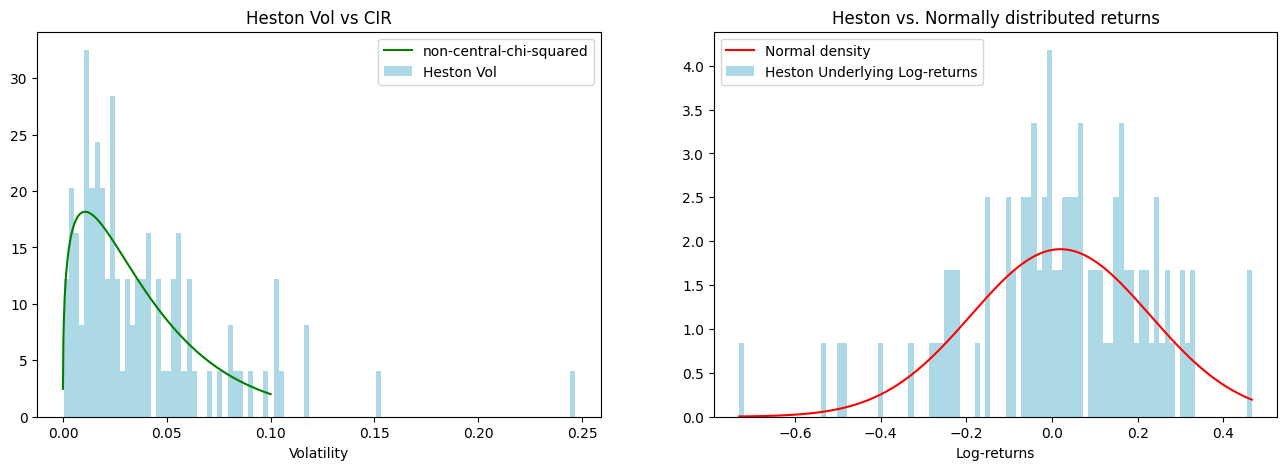

In [13]:
# Obtaining degrees of freedom (do not worry a lot about this now)
c = 2 * kappa_v / ((1 - np.exp(-kappa_v * T)) * sigma_v**2)
df = 4 * kappa_v * theta_v / sigma_v**2
nc = 2 * c * v0 * np.exp(-kappa_v * T)


# Calculating returns and lengths of axis
log_R = np.log(S[-1, :] / S0)
x = np.linspace(log_R.min(), log_R.max(), 500)
y = np.linspace(0.00001, 0.1, 500)


# Plotting the different distributions
fig = plt.figure(figsize=(16, 5))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

# Heston stochastic vol follows a CIR/Vasicek process
ax1.plot(
    y,
    ss.ncx2.pdf(y, df, nc, scale=1 / (2 * c)),
    color="green",
    label="non-central-chi-squared",
)
ax1.hist(V[-1, :], density=True, bins=100, facecolor="LightBlue", label="Heston Vol")
ax1.legend()
ax1.set_title("Heston Vol vs CIR")
ax1.set_xlabel("Volatility")

# Heston underlying returns do not follow a normal distribution
ax2.plot(
    x,
    ss.norm.pdf(x, log_R.mean(), log_R.std(ddof=0)),
    color="r",
    label="Normal density",
)
ax2.hist(
    log_R,
    density=True,
    bins=100,
    facecolor="LightBlue",
    label="Heston Underlying Log-returns",
)
ax2.legend()
ax2.set_title("Heston vs. Normally distributed returns")
ax2.set_xlabel("Log-returns")